
--- Analyzing Fit for s=0.9, p=0.1 ---
Fit Results: gamma = 0.43033, R^2 = 0.97922


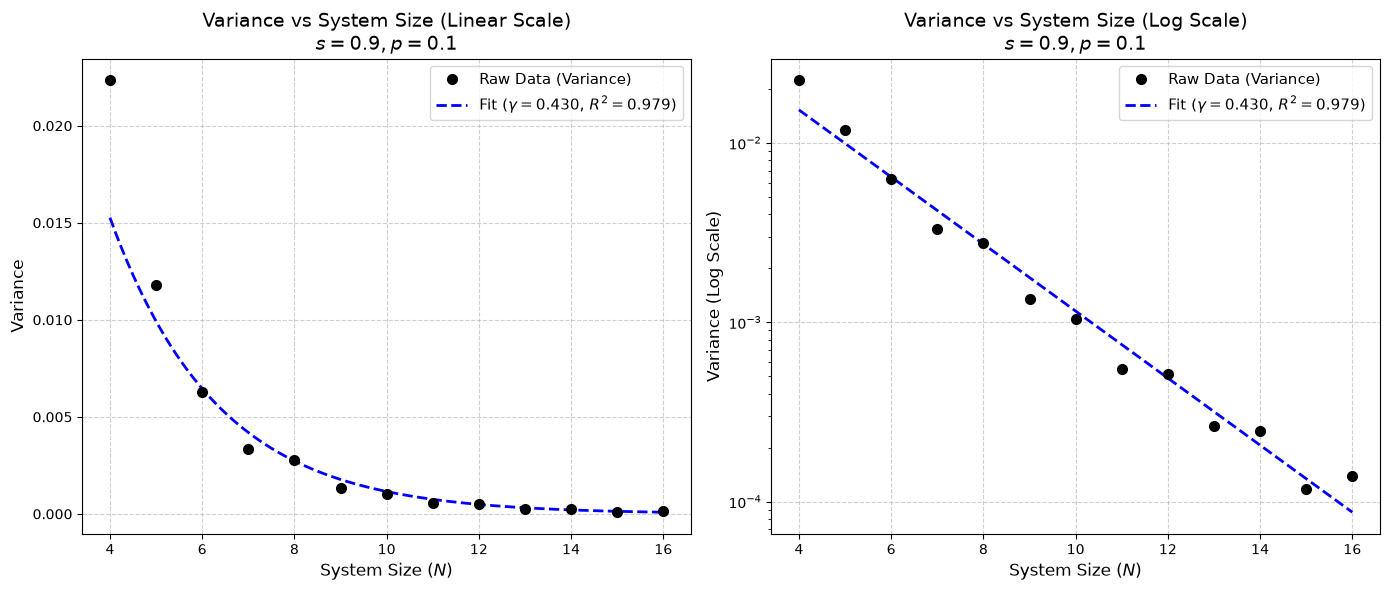

In [ ]:
# variance vs N fit for s and p

import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

def plot_exponential_fit(target_s=1.0, target_p=0.1, input_filepath="sweep_results_N4_16_32bit_3N.pkl"):
    """
    Extracts data for a specific s and p, performs an exponential fit,
    and plots the Variance vs N alongside the goodness-of-fit metrics.
    """
    if not os.path.exists(input_filepath):
        print(f"Error: '{input_filepath}' not found. Please ensure it is in the same directory.")
        return

    with open(input_filepath, "rb") as f:
        data = pickle.load(f)

    if target_s not in data:
        print(f"Error: Measurement strength s={target_s} not found in data.")
        return
        
    p_dict = data[target_s]
    
    if target_p not in p_dict:
        print(f"Error: Measurement rate p={target_p} not found for s={target_s}.")
        print(f"Available p values: {sorted(p_dict.keys())}")
        return

    # Extract data for the specified s and p
    results = p_dict[target_p]
    system_sizes = results.get('system_sizes', [])
    raw_gradients = results.get('raw_gradients', [])
    
    valid_len = min(len(system_sizes), len(raw_gradients))
    if valid_len < 3:
        print("Error: Not enough data points (minimum 3 needed) to perform a fit.")
        return
        
    N_array = np.array(system_sizes[:valid_len], dtype=float)
    variances = np.array([np.var(grads, ddof=1) for grads in raw_gradients[:valid_len]])
    
    # Filter out invalid variances (<= 0) for log safety
    mask = variances > 0
    N_array = N_array[mask]
    variances = variances[mask]

    if len(N_array) < 3:
        print("Error: Not enough valid non-zero variances to perform a fit.")
        return

    print(f"\n--- Analyzing Fit for s={target_s}, p={target_p} ---")

    # =================================================================
    # Exponential Fit (Linear regression on ln(Var) vs N)
    # =================================================================
    Y_log = np.log(variances)
    res = linregress(N_array, Y_log)
    
    gamma = -res.slope
    C = np.exp(res.intercept)
    r2 = res.rvalue**2 
    
    print(f"Fit Results: gamma = {gamma:.5f}, R^2 = {r2:.5f}")

    # =================================================================
    # Plotting
    # =================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Generate smooth points for drawing the fit line
    N_smooth = np.linspace(min(N_array), max(N_array), 200)
    fit_y = C * np.exp(-gamma * N_smooth)
    
    label_fit = f"Fit ($\\gamma={gamma:.3f}$, $R^2={r2:.3f}$)"
    
    # --- Subplot 1: Linear Y-Axis ---
    ax1.plot(N_array, variances, 'ko', markersize=7, label='Raw Data (Variance)', zorder=3)
    ax1.plot(N_smooth, fit_y, 'b--', linewidth=2, label=label_fit, zorder=2)
        
    ax1.set_title(f"Variance vs System Size (Linear Scale)\n$s={target_s}, p={target_p}$", fontsize=14)
    ax1.set_xlabel("System Size ($N$)", fontsize=12)
    ax1.set_ylabel("Variance", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(fontsize=11)

    # --- Subplot 2: Logarithmic Y-Axis ---
    ax2.plot(N_array, variances, 'ko', markersize=7, label='Raw Data (Variance)', zorder=3)
    ax2.plot(N_smooth, fit_y, 'b--', linewidth=2, label=label_fit, zorder=2)
        
    ax2.set_yscale('log')
    ax2.set_title(f"Variance vs System Size (Log Scale)\n$s={target_s}, p={target_p}$", fontsize=14)
    ax2.set_xlabel("System Size ($N$)", fontsize=12)
    ax2.set_ylabel("Variance (Log Scale)", fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(fontsize=11)

    plt.tight_layout()
    # output_filename = f"Var_vs_N_s_{target_s}_p_{target_p}.png"
    # plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    # print(f"\nPlot saved successfully as '{output_filename}'")

if __name__ == "__main__":
    # Specify the target measurement strength (s) and rate (p) here
    plot_exponential_fit(target_s=0.9, target_p=0.1)

Analyzing fits and generating side-by-side plots for s=1.0...

Saved ALL points side-by-side plot to: plots2\Gamma_and_R2_vs_p_s_1.0_all.png
Saved FILTERED side-by-side plot to: plots2\Gamma_and_R2_vs_p_s_1.0_filtered.png


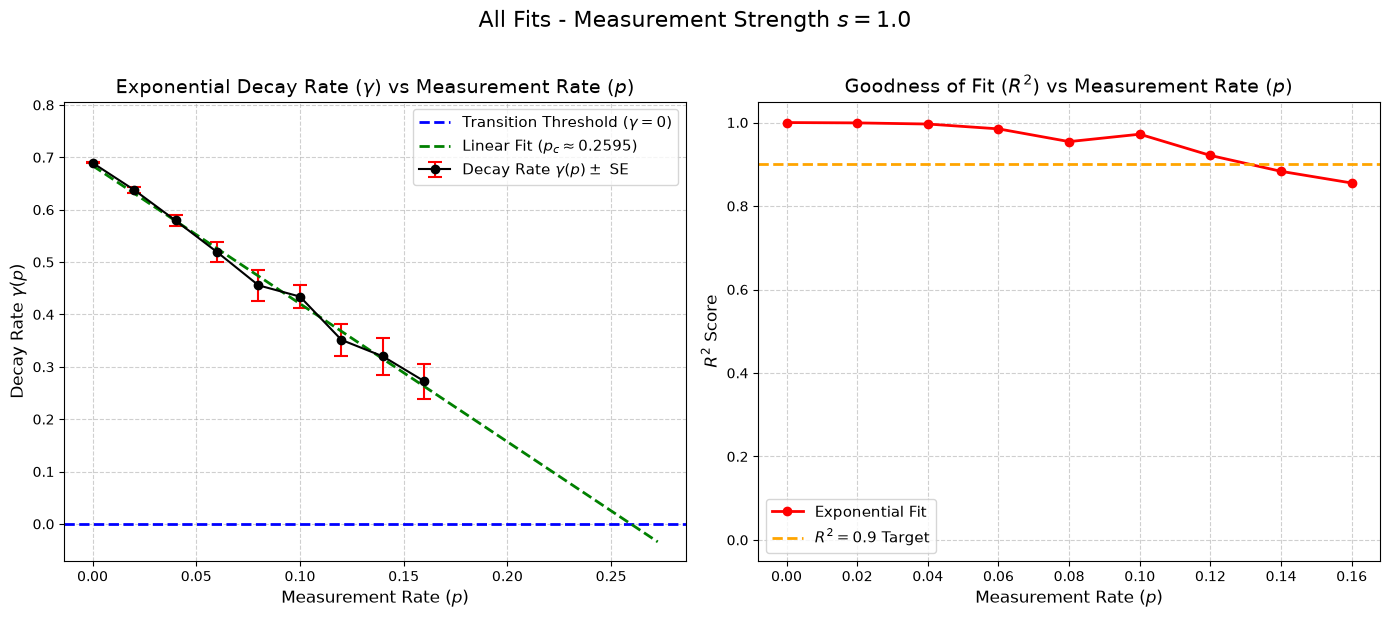

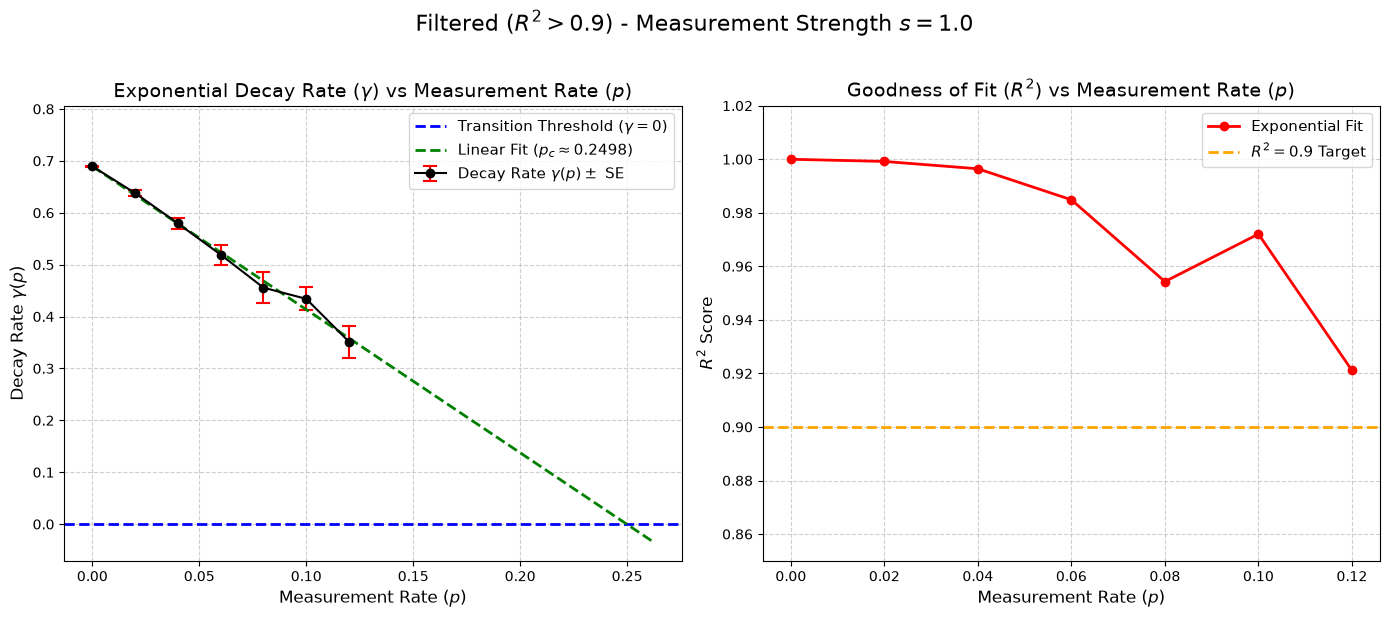

In [ ]:
#  gamma vs p plot for specific strength
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress


def generate_combined_plots(input_filepath, output_dir, target_s, r2_threshold=0.9):
    os.makedirs(output_dir, exist_ok=True)
    
    if not os.path.exists(input_filepath):
        print(f"Error: '{input_filepath}' not found.")
        return

    with open(input_filepath, "rb") as f:
        data = pickle.load(f)

    if target_s not in data:
        print(f"Error: Measurement strength s={target_s} not found in the dataset.")
        return

    p_dict = data[target_s]
    
    # Exclude specific noisy p values if needed
    excluded_p = []

    print(f"Analyzing fits and generating side-by-side plots for s={target_s}...\n")

    p_list = []
    gamma_list = []
    gamma_err_list = []
    r2_list = []
    
    # Sort p to ensure the x-axis plots correctly from left to right
    for p in sorted(p_dict.keys()):
        if p in excluded_p:
            continue
            
        results = p_dict[p]
        system_sizes = results.get('system_sizes', [])
        raw_gradients = results.get('raw_gradients', [])
        
        # Ensure we have enough points for a fit (minimum 3)
        valid_len = min(len(system_sizes), len(raw_gradients))
        if valid_len >= 3:
            N_array = np.array(system_sizes[:valid_len], dtype=float)
            variances = np.array([np.var(grads, ddof=1) for grads in raw_gradients[:valid_len]])
            
            # Protect against log(0) or negative values in case variance is extremely small
            mask = variances > 0
            N_valid = N_array[mask]
            var_valid = variances[mask]
            
            if len(N_valid) < 3:
                continue
                
            Y_log = np.log(var_valid)
            
            # linregress gives slope, standard error, and the correlation coefficient (r)
            # Fit: log(Var) = log(A) - gamma * N
            res = linregress(N_valid, Y_log)
            
            gamma = -res.slope
            gamma_err = res.stderr
            r2 = res.rvalue ** 2  # Square the r-value to get R^2
            
            p_list.append(p)
            gamma_list.append(gamma)
            gamma_err_list.append(gamma_err)
            r2_list.append(r2)
    
    if not p_list:
        print(f"No valid data points could be extracted for s={target_s}.")
        return

    # ======================================================================
    # PLOT 1: All Data with Threshold Lines and Linear Extrapolation
    # ======================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Subplot 1: Gamma vs p
    ax1.errorbar(p_list, gamma_list, yerr=gamma_err_list, fmt='ko-', 
                 capsize=5, capthick=1.5, ecolor='red', markersize=6, 
                 label=r'Decay Rate $\gamma(p) \pm$ SE')
    
    ax1.axhline(0, color='blue', linestyle='--', linewidth=2, label=r'Transition Threshold ($\gamma = 0$)')
        
    # Linear fit and extraction of p_c
    if len(p_list) >= 2:
        fit_all = linregress(p_list, gamma_list)
        slope_all, intercept_all = fit_all.slope, fit_all.intercept
        pc_all = -intercept_all / slope_all if slope_all != 0 else float('nan')
        
        # Create extrapolated line array that slightly passes p_c
        p_max_ext = max(p_list)
        if not np.isnan(pc_all) and pc_all > 0:
            p_max_ext = max(p_max_ext, pc_all * 1.05)
            
        p_line_all = np.linspace(min(p_list), p_max_ext, 100)
        gamma_line_all = slope_all * p_line_all + intercept_all
        
        ax1.plot(p_line_all, gamma_line_all, 'g--', linewidth=2, label=f'Linear Fit ($p_c \\approx {pc_all:.4f}$)')
    
    ax1.set_title(r"Exponential Decay Rate ($\gamma$) vs Measurement Rate ($p$)", fontsize=14)
    ax1.set_xlabel("Measurement Rate ($p$)", fontsize=12)
    ax1.set_ylabel(r"Decay Rate $\gamma(p)$", fontsize=12)
    
    y_min, y_max = ax1.get_ylim()
    # Adjust y-limit down to include the extrapolated gamma=0 line clearly
    ax1.set_ylim(min(y_min, -0.05), y_max + (y_max - y_min) * 0.1) 
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(fontsize=11, loc='best')
    
    # Subplot 2: R^2 vs p
    ax2.plot(p_list, r2_list, 'ro-', linewidth=2, label='Exponential Fit')
    ax2.axhline(r2_threshold, color='orange', linestyle='--', linewidth=2, label=f'$R^2 = {r2_threshold}$ Target')
    
    ax2.set_title(r"Goodness of Fit ($R^2$) vs Measurement Rate ($p$)", fontsize=14)
    ax2.set_xlabel("Measurement Rate ($p$)", fontsize=12)
    ax2.set_ylabel(r"$R^2$ Score", fontsize=12)
    
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(fontsize=11, loc='best')
    
    fig.suptitle(f"All Fits - Measurement Strength $s = {target_s}$", fontsize=16, y=1.02)
    plt.tight_layout()
    
    save_path_all = os.path.join(output_dir, f"Gamma_and_R2_vs_p_s_{target_s}_all.png")
    # plt.savefig(save_path_all, dpi=300, bbox_inches='tight')
    # plt.close()

    
    print(f"Saved ALL points side-by-side plot to: {save_path_all}")

    # ======================================================================
    # PLOT 2: Filtered Data (Only R^2 > threshold) with Extrapolation
    # ======================================================================
    filt_p, filt_g, filt_g_err, filt_r2 = [], [], [], []
    for p_val, g, g_err, r2 in zip(p_list, gamma_list, gamma_err_list, r2_list):
        if r2 > r2_threshold:
            filt_p.append(p_val)
            filt_g.append(g)
            filt_g_err.append(g_err)
            filt_r2.append(r2)

    if len(filt_p) > 0:
        fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))
        
        # Subplot 1 (Filtered): Gamma vs p
        ax3.errorbar(filt_p, filt_g, yerr=filt_g_err, fmt='ko-', 
                     capsize=5, capthick=1.5, ecolor='red', markersize=6, 
                     label=r'Decay Rate $\gamma(p) \pm$ SE')
        
        ax3.axhline(0, color='blue', linestyle='--', linewidth=2, label=r'Transition Threshold ($\gamma = 0$)')
        
        # Linear fit and extraction of p_c for filtered data
        if len(filt_p) >= 2:
            fit_filt = linregress(filt_p, filt_g)
            slope_filt, intercept_filt = fit_filt.slope, fit_filt.intercept
            pc_filt = -intercept_filt / slope_filt if slope_filt != 0 else float('nan')
            
            p_max_ext_f = max(filt_p)
            if not np.isnan(pc_filt) and pc_filt > 0:
                p_max_ext_f = max(p_max_ext_f, pc_filt * 1.05)
                
            p_line_filt = np.linspace(min(filt_p), p_max_ext_f, 100)
            gamma_line_filt = slope_filt * p_line_filt + intercept_filt
            
            ax3.plot(p_line_filt, gamma_line_filt, 'g--', linewidth=2, label=f'Linear Fit ($p_c \\approx {pc_filt:.4f}$)')
        
        ax3.set_title(r"Exponential Decay Rate ($\gamma$) vs Measurement Rate ($p$)", fontsize=14)
        ax3.set_xlabel("Measurement Rate ($p$)", fontsize=12)
        ax3.set_ylabel(r"Decay Rate $\gamma(p)$", fontsize=12)
        
        y_min, y_max = ax3.get_ylim()
        ax3.set_ylim(min(y_min, -0.05), y_max + (y_max - y_min) * 0.1)
        ax3.grid(True, linestyle='--', alpha=0.6)
        ax3.legend(fontsize=11, loc='best')
        
        # Subplot 2 (Filtered): R^2 vs p
        ax4.plot(filt_p, filt_r2, 'ro-', linewidth=2, label='Exponential Fit')
        ax4.axhline(r2_threshold, color='orange', linestyle='--', linewidth=2, label=f'$R^2 = {r2_threshold}$ Target')
        
        ax4.set_title(r"Goodness of Fit ($R^2$) vs Measurement Rate ($p$)", fontsize=14)
        ax4.set_xlabel("Measurement Rate ($p$)", fontsize=12)
        ax4.set_ylabel(r"$R^2$ Score", fontsize=12)
        
        ax4.set_ylim(r2_threshold - 0.05, 1.02)
        ax4.grid(True, linestyle='--', alpha=0.6)
        ax4.legend(fontsize=11, loc='best')
        
        fig2.suptitle(f"Filtered ($R^2 > {r2_threshold}$) - Measurement Strength $s = {target_s}$", fontsize=16, y=1.02)
        plt.tight_layout()
        
        save_path_filtered = os.path.join(output_dir, f"Gamma_and_R2_vs_p_s_{target_s}_filtered.png")
        # plt.savefig(save_path_filtered, dpi=300, bbox_inches='tight')
        # plt.close(fig2)
        
        print(f"Saved FILTERED side-by-side plot to: {save_path_filtered}")
    else:
        print(f"Skipping filtered plot: No data points passed the R² > {r2_threshold} threshold.")

if __name__ == "__main__":
    # Specify the exact file, measurement strength, and R2 threshold here
    input_file = "sweep_results_N4_16_32bit_3N.pkl"
    output_directory = "plots2"
    s_value = 1.0
    threshold = 0.9
    
    generate_combined_plots(
        input_filepath=input_file, 
        output_dir=output_directory, 
        target_s=s_value, 
        r2_threshold=threshold
    )

Analyzing dataset to extract p_c for each s...

s = 0.1: p_c ≈ 5.7752
s = 0.2: p_c ≈ 1.4973
s = 0.3: p_c ≈ 0.7956
s = 0.4: p_c ≈ 0.5319
s = 0.5: p_c ≈ 0.3976
s = 0.6: p_c ≈ 0.3186
s = 0.7: p_c ≈ 0.2947
s = 0.8: p_c ≈ 0.2769
s = 0.9: p_c ≈ 0.2622
s = 1.0: p_c ≈ 0.2595

Saved phase diagram to: plots\Phase_Diagram_s_vs_pc.png


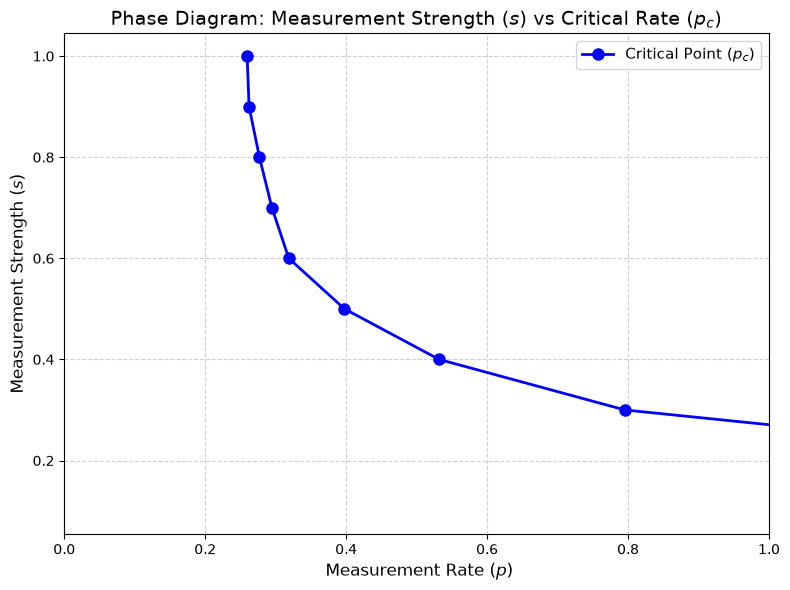

In [ ]:
# strength vs p with critical points according to linear fit 

import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

def generate_phase_diagram(input_filepath, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    
    if not os.path.exists(input_filepath):
        print(f"Error: '{input_filepath}' not found.")
        return

    with open(input_filepath, "rb") as f:
        data = pickle.load(f)

    s_values = []
    pc_values = []

    print("Analyzing dataset to extract p_c for each s...\n")

    # Iterate over all measurement strengths in the dataset
    for s in sorted(data.keys()):
        p_dict = data[s]
        
        p_list = []
        gamma_list = []
        
        # Calculate gamma for each p under the current s
        for p in sorted(p_dict.keys()):
            results = p_dict[p]
            system_sizes = results.get('system_sizes', [])
            raw_gradients = results.get('raw_gradients', [])
            
            valid_len = min(len(system_sizes), len(raw_gradients))
            if valid_len >= 3:
                N_array = np.array(system_sizes[:valid_len], dtype=float)
                variances = np.array([np.var(grads, ddof=1) for grads in raw_gradients[:valid_len]])
                
                mask = variances > 0
                N_valid = N_array[mask]
                var_valid = variances[mask]
                
                if len(N_valid) >= 3:
                    Y_log = np.log(var_valid)
                    res = linregress(N_valid, Y_log)
                    
                    gamma = -res.slope
                    p_list.append(p)
                    gamma_list.append(gamma)
        
        # Linearly extrapolate to find p_c where gamma = 0
        if len(p_list) >= 2:
            fit = linregress(p_list, gamma_list)
            if fit.slope != 0:
                pc = -fit.intercept / fit.slope
                s_values.append(s)
                pc_values.append(pc)
                print(f"s = {s}: p_c ≈ {pc:.4f}")
            else:
                print(f"s = {s}: Slope is zero, cannot extrapolate p_c.")
        else:
            print(f"s = {s}: Insufficient data points to fit gamma vs p.")

    if not s_values:
        print("\nNo valid p_c values could be extracted.")
        return

    # ======================================================================
    # PLOT: Phase Diagram (s vs p_c)
    # ======================================================================
    plt.figure(figsize=(8, 6))
    
    # Plot s on y-axis and pc on x-axis
    plt.plot(pc_values, s_values, 'bo-', linewidth=2, markersize=8, label=r'Critical Point ($p_c$)')
    
    plt.title(r"Phase Diagram: Measurement Strength ($s$) vs Critical Rate ($p_c$)", fontsize=14)
    plt.xlabel(r" Measurement Rate ($p$)", fontsize=12)
    plt.ylabel(r"Measurement Strength ($s$)", fontsize=12)
    plt.xlim(0,1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    save_path = os.path.join(output_dir, "Phase_Diagram_s_vs_pc.png")
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"\nSaved phase diagram to: {save_path}")

if __name__ == "__main__":
    input_file = "sweep_results_N4_16_32bit_3N.pkl"
    output_directory = "plots"
    
    generate_phase_diagram(
        input_filepath=input_file, 
        output_dir=output_directory
    )